# Group Project Machine Learning 2024/2025
Group formed by Aitor Mentxaka, Miguel Rascón and Marcos de Miguel.

aitor.mentxaka@estudiante.uam.es,
miguel.rascon@estudiante.uam.es,
marcos.demiguelv@estudiante.uam.es.

This project was developed following these guidelines:

https://github.com/stefanogiagu/corso_AI_2025/blob/main/ProgettoGruppo/MetodiAI_Fis2025_GroupProject.ipynb


In [ ]:
import numpy as np
np.set_printoptions(precision=8, suppress=False)
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

!pip install umap-learn

import umap
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

2.6.0+cu124
0.21.0+cu124


# Quick Data Analysis
First, all data is downloaded in three datasets: normal data, low anomaly data and high anomaly data. We expect the high anomaly data to contain >55% of anomaly data and <45% for low anomaly data.

The normal data will further be divided into train data (80%) and test data (20%). The trian data will be used as input for the autoencoder, and the test data will be used to measure both the quality of the autoencoder and as reference for the anomaly percentage.

In [ ]:
#load and print data

!wget http://giagu.web.cern.ch/giagu/CERN/P2025/Normal_data.npz
!wget http://giagu.web.cern.ch/giagu/CERN/P2025/G51/Test_data_low.npz
!wget http://giagu.web.cern.ch/giagu/CERN/P2025/G51/Test_data_high.npz

f_train = np.load('Normal_data.npz')
f_test_l = np.load('Test_data_low.npz')
f_test_h = np.load('Test_data_high.npz')

datos_normal = f_train['normal_data'] #datos normales (sin anomalias)
test_data_l = f_test_l['test_data'] #datos anomalos (low)
test_data_h = f_test_h['test_data'] #datos anomalos (high)

--2025-07-17 13:43:20--  http://giagu.web.cern.ch/giagu/CERN/P2025/Normal_data.npz
Resolving giagu.web.cern.ch (giagu.web.cern.ch)... 137.138.55.232, 188.185.5.88, 188.185.50.104, ...
Connecting to giagu.web.cern.ch (giagu.web.cern.ch)|137.138.55.232|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://giagu.web.cern.ch/giagu/CERN/P2025/Normal_data.npz [following]
--2025-07-17 13:43:20--  https://giagu.web.cern.ch/giagu/CERN/P2025/Normal_data.npz
Connecting to giagu.web.cern.ch (giagu.web.cern.ch)|137.138.55.232|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6874623 (6.6M)
Saving to: ‘Normal_data.npz’

Normal_data.npz     100%[===================>]   6.56M  4.65MB/s    in 1.4s    

2025-07-17 13:43:22 (4.65 MB/s) - ‘Normal_data.npz’ saved [6874623/6874623]

--2025-07-17 13:43:22--  http://giagu.web.cern.ch/giagu/CERN/P2025/G51/Test_data_low.npz
Resolving giagu.web.cern.ch (giagu.web.cern.ch)... 137.138.55.232, 188.185.50.104, 

NameError: name 'np' is not defined

Train shape: (9600, 100, 100)
Validation shape: (2400, 100, 100)
test_data_low.shape: (3000, 100, 100)
test_data_high.shape: (3000, 100, 100)


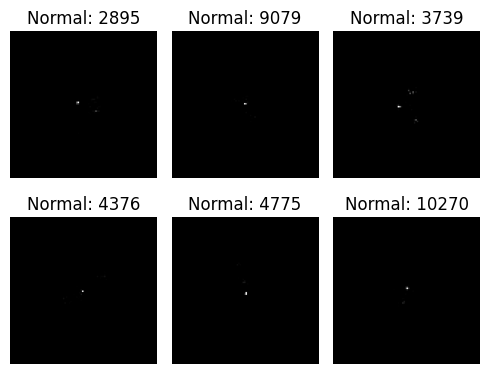

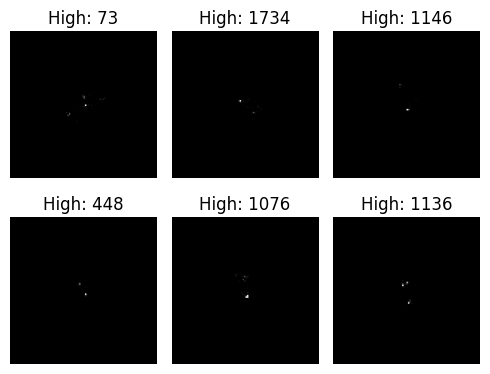

In [ ]:
# split train dataset into Xtrain (80%) and Xval (20%)

from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(datos_normal, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_test.shape}")
print(f'test_data_low.shape: {test_data_l.shape}')
print(f'test_data_high.shape: {test_data_h.shape}')

# Plot to generate 6 random images to get an intuition of our data.

num_images = datos_normal.shape[0]
random_indices = np.random.choice(num_images, size=6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(5, 4))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    axes[i].imshow(datos_normal[idx,:,:], cmap='grey')
    axes[i].set_title(f'Normal: {idx}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(5, 4))
axes = axes.flatten()
random_indices = np.random.choice(3000, size=6, replace=False)
for i, idx in enumerate(random_indices):
    axes[i].imshow(test_data_h[idx,:,:], cmap='grey')
    axes[i].set_title(f'High: {idx}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Six random data samples are displayed to get a preview of our data's nature. It is noted that they are formed by what seems as small measures in our detector. They do not seem to form highly complex patterns with a myriad of features, as seen in numbers or image detection.

Anomaly data is also plotted, but there is not a clear enough visible pattern.




### Normalization
As a group, data **normalization** was a great point of discussion. On one hand, it was argued that normalization would help us in PCA dimension reduction, flexibility with MSE or BCE Losses and overall improve our system's consistency.

On the other hand, it was also argued that our data is already on greyscale, and on the same physical dimensions. Moreover, it could be the case where an absolute value regarding a **physical magnitude**, such us energy, could provide meaningful information for our dataset.

Thus, it was concluded that **normalization was not necessarily needed as it won't affect PCA directions meaningfully**, eventhough it would restrain us to use the MCE Loss function.

## PCA reduction
First of all, a PCA dimension reduction was applied to our data. The objective for this process are not only to get an intuition of how our data is distributed, but to discuss the number of dimensions that could appropietly fit our data.




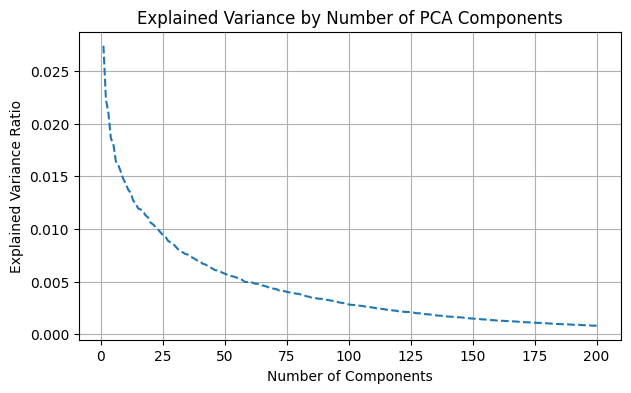

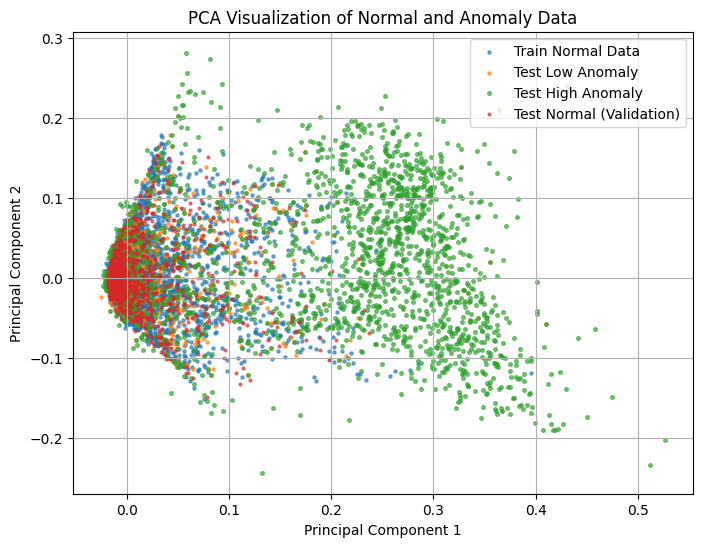

In [ ]:
# Initialize PCA
pca = PCA(n_components=200)

X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)
test_data_l_reshaped = test_data_l.reshape(test_data_l.shape[0], -1)
test_data_h_reshaped = test_data_h.reshape(test_data_h.shape[0], -1)


pca.fit(X_train_reshaped)
datos_normal_pca = pca.transform(X_train_reshaped)
test_data_normal_pca = pca.transform(X_test_reshaped)
test_data_l_pca = pca.transform(test_data_l_reshaped)
test_data_h_pca = pca.transform(test_data_h_reshaped)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(7, 4))
plt.plot(range(1, pca.n_components_ + 1), explained_variance_ratio, linestyle='--')
plt.title('Explained Variance by Number of PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 6))
#scatter = plt.scatter(combined_pca_data[:, 0], combined_pca_data[:, 1], c=data_labels, cmap='viridis', s=10, alpha=0.6)
plt.scatter(datos_normal_pca[:, 0], datos_normal_pca[:, 1],
            s=5, label='Train Normal Data', alpha=0.6)
plt.scatter(test_data_l_pca[:, 0], test_data_l_pca[:, 1],
            s=5, label='Test Low Anomaly', alpha=0.6)
plt.scatter(test_data_h_pca[:, 0], test_data_h_pca[:, 1],
            s=7, label='Test High Anomaly', alpha=0.6)
plt.scatter(test_data_normal_pca[:, 0], test_data_normal_pca[:, 1],
            s=4, label='Test Normal (Validation)', alpha=0.6)
plt.title('PCA Visualization of Normal and Anomaly Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

### Data Analysis

First of all, we can see how our data distributes and we can build a preliminary intuition about our data.

The PCA shows that the anomaly data "has a tendency to the right". Moreover, note how the high anomaly data not only has a much higher number of anomaly data than the low dataset, but it's anomalys are **much more pronunciated**. This is seen as the anomalys belonging to the high anomaly dataset are further to right than the lower anomaly dataset.

Overall, this means the low anomaly dataset does **not only** contain **less number** of anomalies, but they are **less differenciated** as well. To differenciate these anomalies will be a further challenge for our Autoencoder.



###Latent Space Dimensions through PCA
Moreover, another objective was to get a quick approximation for the number of latent space dimensions for our Autoencoder through the so-called '**elbow method**'.

 Nevertheless, we have *not obtained valid results*, as we do not observe a clear breaking point. Even though our PCA does reach enough covariance, it is not until the 175th dimension, which we consider is too high considering our data complexity.

 In conclusion, we consider this apporoach *does not perfectly fit our data*, perhaps due to the inhability of PCA to recognise non-lineal patterns. Therefore we will try other methods to determine the latent space dimension.


Next, we continue with the necessary data conversion into pytorch tensors to feed the Autoencoder.

In [ ]:
# Formato numpy => pytorch
X_train = torch.Tensor(X_train).float()
X_test = torch.Tensor(X_test).float()

datah = torch.Tensor(test_data_h).float()
datal = torch.Tensor(test_data_l).float()

# train.view para meter el 1 de canales (ByN)
X_train = X_train.view((X_train.shape[0],1,100,100))
X_test = X_test.view((X_test.shape[0],1,100,100))

datah = datah.view((datah.shape[0],1,100,100))
datal = datal.view((datal.shape[0],1,100,100))

print(f'type: {type(X_train)}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'datah shape: {datah.shape}')
print(f'datal shape: {datal.shape}')


X_TensorDataset = TensorDataset(X_train, X_train) # TensorDataset(input, labels) => input=labels por ser Autoencoder
  #NOTA: El TensorDataset no tiene shape, pero cada uno de sus tensores si
datah_TensorDataset = TensorDataset(datah,datah)
datal_TensorDataset = TensorDataset(datal,datal)


type: <class 'torch.Tensor'>
X_train shape: torch.Size([9600, 1, 100, 100])
X_test shape: torch.Size([2400, 1, 100, 100])
datah shape: torch.Size([3000, 1, 100, 100])
datal shape: torch.Size([3000, 1, 100, 100])


# Autoencoder


Only now we can start with the Autoencoder's construction. The AE's architecture has been one of the main points of our investigation.

The data we are working with has the shape (N,1,100,100). This is because we have N examples (images) with 1 channel (grays image) of 100x100 pixels.  


The Encoder consists of 4 convolutional 2d layers. What we are trying to do with this layers is to reduce dimensionality (downsampling), but in order to do this without losing information, we must increase the richness of the feature channels. To achieve this, each layer increases channels in the following way:
1: 1 → 32 channels
2: 32 → 64 channels
3: 64 → 96 channels
4: 96 → 128 channels
The form we have used in Kernels (3x3) and Strides (2x2) to reduce dimensionality is square. This is because we do not find any reason to think that there are asymmetries (this can be noticed just by looking at the example images).

The Decoder does exactly the opposite. It’s convolutional layers try to increase the dimensionality while reducing the channels, until recovering the original space. However, sometimes the final size is not equal to the original one, so it is required to adjust this by using padding. In our case, we have used out_padding equal to (1,1) in transpose convolutional layers 4, 3 and 1.

As for the latent space dimension, we have chosen a value of 64. By means of the scree plot we have not observed an elbow to assign an optimal value, so this value has been chosen as an intermediate point.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, hidden_channels=32, latent_dim=64):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=hidden_channels,
                               kernel_size=(3,3),
                               stride=(2,2))

        self.conv2 = nn.Conv2d(in_channels=hidden_channels,
                               out_channels=hidden_channels*2,
                               kernel_size=(3,3),
                               stride=(2,2))

        self.conv3 = nn.Conv2d(in_channels=hidden_channels*2,
                               out_channels=hidden_channels*3,
                               kernel_size=(3,3),
                               stride=(2,2))

        self.conv4 = nn.Conv2d(in_channels=hidden_channels*3,
                               out_channels=hidden_channels*4,
                               kernel_size=(2,2),
                               stride=(2,2))

        self.activation = nn.ReLU()

        #dynamic adjust
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, 100, 100)
            x = self.activation(self.conv1(dummy_input))
            x = self.activation(self.conv2(x))
            x = self.activation(self.conv3(x))
            print(f"Encoder final shape: {x.shape}")
            flattened_size = x.view(x.shape[0], -1).size(1)
        self.fc_z = nn.Linear(in_features=flattened_size,
                               out_features=latent_dim)


    def forward(self, x):

        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))
        x = self.activation(self.conv3(x))

        x = x.view(x.shape[0], -1) #flatten

        z = self.fc_z(x)

        return z

encoder = Encoder()

Encoder final shape: torch.Size([1, 96, 11, 11])
Encoder flattened size for fc_z: 11616


In [ ]:
class Decoder(nn.Module):
    def __init__(self, hidden_channels=32, latent_dim=64):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.fc = nn.Linear(in_features=latent_dim,
                            out_features=hidden_channels*3*11*11)

        self.conv4 = nn.ConvTranspose2d(in_channels=hidden_channels*4,
                                        out_channels=hidden_channels*3,
                                        kernel_size=(3,3),
                                        stride=(2,2),output_padding=(1,1))

        self.conv3 = nn.ConvTranspose2d(in_channels=hidden_channels*3,
                                        out_channels=hidden_channels*2,
                                        kernel_size=(3,3),
                                        stride=(2,2),output_padding=(1,1))

        self.conv2 = nn.ConvTranspose2d(in_channels=hidden_channels*2,
                                        out_channels=hidden_channels,
                                        kernel_size=(3,3),
                                        stride=(2,2))

        self.conv1 = nn.ConvTranspose2d(in_channels=hidden_channels,
                                        out_channels=1,
                                        kernel_size=(3,3),
                                        stride=(2,2),output_padding=(1,1))

        self.activation = nn.ReLU()


    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), self.hidden_channels*3, 11, 11)
        x = self.activation(self.conv3(x))
        x = self.activation(self.conv2(x))
        out = self.conv1(x)
        return out

**GPUs** are much more efficient at carrying out multiple simple calculations at the same time, which fits perfectly with use for Convulutional Neuronal Networks.

In [ ]:
if torch.cuda.is_available():
  print('GPU available: ',torch.cuda.device_count())
  for i in range(0,torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))


device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

GPU available:  1
Tesla T4
Computation device: cuda



Finally we can build the full autoencoder: Encoder + Decoder

In [ ]:
class AE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        z = self.encoder(x)       # x-> z
        x_recon = self.decoder(z) # z -> x'

        return x_recon

We check the encoder's info and define our *model* into our selected *device*.


In [ ]:
encoder = Encoder().to(device)
decoder = Decoder().to(device)

model = AE(encoder, decoder).to(device)
print(model)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model.cuda(), input_size=(1,100,100))
else:
  summary(model, input_size=(1,100,100))

Encoder final shape: torch.Size([1, 96, 11, 11])
Encoder flattened size for fc_z: 11616
AE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (conv3): Conv2d(64, 96, kernel_size=(3, 3), stride=(2, 2))
    (conv4): Conv2d(96, 128, kernel_size=(2, 2), stride=(2, 2))
    (activation): ReLU()
    (fc_z): Linear(in_features=11616, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=64, out_features=11616, bias=True)
    (conv4): ConvTranspose2d(128, 96, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (conv3): ConvTranspose2d(96, 64, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (conv2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2))
    (conv1): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (activation): ReLU()
  )
)
----------------------------------------------------------------


# Autoencoder's training
Training data is feeded in order to properly train the autoencoder.

Following a few attemps, the **Batch size** was finally selected quite low in order to avoid underfitting and overloading the GPU's RAM memory.

In addition, the **MSE Loss** was a forced choice as a result of not normalizing the datasets. With the BCE Loss function, the sigmoid function at the activation layer would feed error into our system.

Starting training...
Epoch [1/40], Loss: 0.0125
Epoch [2/40], Loss: 0.0103
Epoch [3/40], Loss: 0.0065
Epoch [4/40], Loss: 0.0043
Epoch [5/40], Loss: 0.0031
Epoch [6/40], Loss: 0.0024
Epoch [7/40], Loss: 0.0020
Epoch [8/40], Loss: 0.0017
Epoch [9/40], Loss: 0.0015
Epoch [10/40], Loss: 0.0014
Epoch [11/40], Loss: 0.0013
Epoch [12/40], Loss: 0.0012
Epoch [13/40], Loss: 0.0012
Epoch [14/40], Loss: 0.0011
Epoch [15/40], Loss: 0.0011
Epoch [16/40], Loss: 0.0010
Epoch [17/40], Loss: 0.0010
Epoch [18/40], Loss: 0.0010
Epoch [19/40], Loss: 0.0010
Epoch [20/40], Loss: 0.0009
Epoch [21/40], Loss: 0.0009
Epoch [22/40], Loss: 0.0009
Epoch [23/40], Loss: 0.0009
Epoch [24/40], Loss: 0.0009
Epoch [25/40], Loss: 0.0008
Epoch [26/40], Loss: 0.0008
Epoch [27/40], Loss: 0.0008
Epoch [28/40], Loss: 0.0008
Epoch [29/40], Loss: 0.0008
Epoch [30/40], Loss: 0.0007
Epoch [31/40], Loss: 0.0007
Epoch [32/40], Loss: 0.0007
Epoch [33/40], Loss: 0.0007
Epoch [34/40], Loss: 0.0007
Epoch [35/40], Loss: 0.0007
Epoch [3

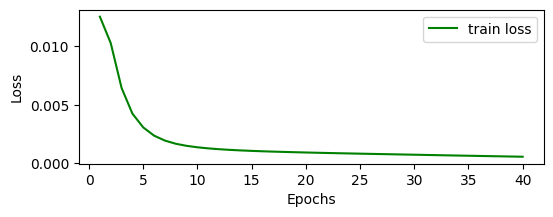

In [ ]:
batch_size = 128

dataloader = DataLoader(X_TensorDataset, batch_size=batch_size, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

num_epochs = 40
hist_loss = []

print("Train start")
for epoch in range(num_epochs):
    total_loss = 0
    for data in dataloader:
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    hist_loss.append(total_loss/len(dataloader))

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader):.4f}')

print("Training finish")

plt.figure(figsize=(6,2))
plt.plot(range(1,len(hist_loss)+1), hist_loss, color='red', linestyle='-', label='train loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

We consider this training good enough, as the loss is greatly minimized. The number of epochs could have been reduced, but we chose to keep it slightly higher, sacrificing some computational time to achieve better accuracy.

## Latent space reduction
As discussed earlier, the latent space has 64 dimensions.
We can use dimension reduction to visualize the autooencoder's latent space structure.

A PCA was applied at first in order to quickly visualize the latent space.

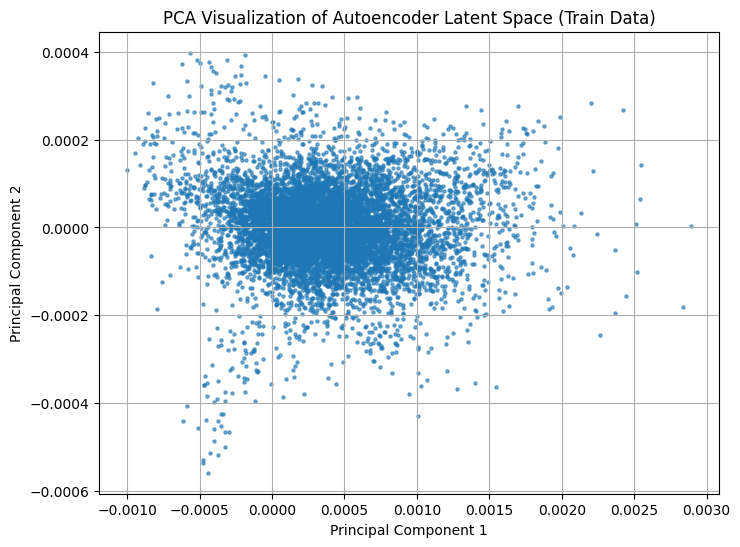

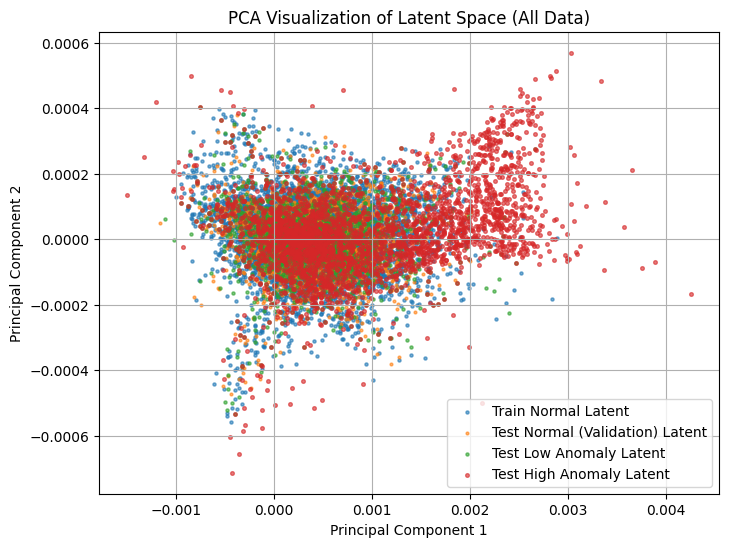

Two components explained variance ratio:  [9.9329358e-01 4.9293024e-04]


In [ ]:
# Function to get latent representations
def get_latent_representation(model, dataloader, device):
    model.eval()
    latent_vectors = []
    with torch.no_grad():
        for data in dataloader:
            inputs, _ = data
            inputs = inputs.to(device)
            z = model.encoder(inputs)
            latent_vectors.append(z.cpu().numpy())
    return np.concatenate(latent_vectors, axis=0)

X_train_latent = get_latent_representation(model, dataloader, device)

pca_latent = PCA(n_components=2)

X_train_latent_pca = pca_latent.fit_transform(X_train_latent)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_latent_pca[:, 0], X_train_latent_pca[:, 1], s=5, alpha=0.6)
plt.title('PCA Visualization of Autoencoder Latent Space (Train Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

#we create new dataloaders, with appropiate batch size, just in case
dataloader_test_normal = DataLoader(TensorDataset(X_test, X_test), batch_size=batch_size, shuffle=False)
dataloader_test_low = DataLoader(datal_TensorDataset, batch_size=batch_size, shuffle=False)
dataloader_test_high = DataLoader(datah_TensorDataset, batch_size=batch_size, shuffle=False)

#latent representation
X_test_latent = get_latent_representation(model, dataloader_test_normal, device)
test_data_l_latent = get_latent_representation(model, dataloader_test_low, device)
test_data_h_latent = get_latent_representation(model, dataloader_test_high, device)

#pca transformation
X_test_latent_pca = pca_latent.transform(X_test_latent)
test_data_l_latent_pca = pca_latent.transform(test_data_l_latent)
test_data_h_latent_pca = pca_latent.transform(test_data_h_latent)

# all datatypes visualization
plt.figure(figsize=(8, 6))
plt.scatter(X_train_latent_pca[:, 0], X_train_latent_pca[:, 1],
            s=5, label='Train Normal Latent', alpha=0.6)
plt.scatter(X_test_latent_pca[:, 0], X_test_latent_pca[:, 1],
            s=4, label='Test Normal (Validation) Latent', alpha=0.6)
plt.scatter(test_data_l_latent_pca[:, 0], test_data_l_latent_pca[:, 1],
            s=5, label='Test Low Anomaly Latent', alpha=0.6)
plt.scatter(test_data_h_latent_pca[:, 0], test_data_h_latent_pca[:, 1],
            s=7, label='Test High Anomaly Latent', alpha=0.6)
plt.title('PCA Visualization of Latent Space (All Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

explained_variance_ratio_latent = pca_latent.explained_variance_ratio_
print(f"Two components explained variance ratio:  {explained_variance_ratio_latent}")



Moreover, we have considered it might be more useful to use UMAP, as it provides a more useful representation for non-linear structures.



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


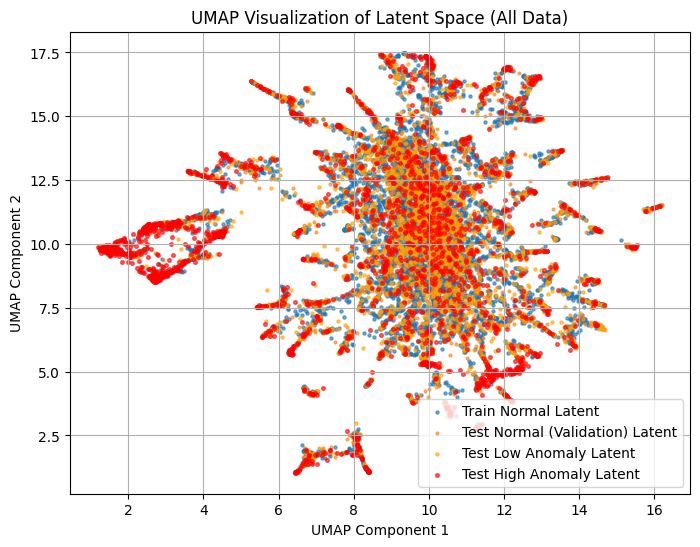

In [ ]:
model.eval()
device = next(model.parameters()).device # Get the device from the model

# Get independent latent representations for all data
with torch.no_grad():
    # Train Normal Data
    X_train_device = X_train.to(device)
    latent_space_train = model.encoder(X_train_device)
    latent_space_train_np = latent_space_train.cpu().numpy()

    # Test Normal Data (Validation)
    # Assuming X_test is already a Tensor and on the correct device or can be moved
    X_test_device = X_test.to(device)
    latent_space_test_normal = model.encoder(X_test_device)
    latent_space_test_normal_np = latent_space_test_normal.cpu().numpy()

    # Test Low Anomaly Data
    # Assuming datal is already a Tensor and on the correct device or can be moved
    datal_device = datal.to(device)
    latent_space_low_anomaly = model.encoder(datal_device)
    latent_space_low_anomaly_np = latent_space_low_anomaly.cpu().numpy()

    # Test High Anomaly Data
    # Assuming datah is already a Tensor and on the correct device or can be moved
    datah_device = datah.to(device)
    latent_space_high_anomaly = model.encoder(datah_device)
    latent_space_high_anomaly_np = latent_space_high_anomaly.cpu().numpy()

umap_reducer = umap.UMAP(n_components=2, random_state=42)
latent_space_train_umap = umap_reducer.fit_transform(latent_space_train_np)
#we get umap representation
latent_space_test_normal_umap = umap_reducer.transform(latent_space_test_normal_np)
latent_space_low_anomaly_umap = umap_reducer.transform(latent_space_low_anomaly_np)
latent_space_high_anomaly_umap = umap_reducer.transform(latent_space_high_anomaly_np)

#plotting
plt.figure(figsize=(8, 6))

plt.scatter(latent_space_train_umap[:, 0], latent_space_train_umap[:, 1],
            s=5, label='Train Normal Latent', alpha=0.6)
plt.scatter(latent_space_test_normal_umap[:, 0], latent_space_test_normal_umap[:, 1],
            s=4, label='Test Normal (Validation) Latent', alpha=0.6)
plt.scatter(latent_space_low_anomaly_umap[:, 0], latent_space_low_anomaly_umap[:, 1],
            s=5, label='Test Low Anomaly Latent', alpha=0.6, color='orange') # Use different color
plt.scatter(latent_space_high_anomaly_umap[:, 0], latent_space_high_anomaly_umap[:, 1],
            s=7, label='Test High Anomaly Latent', alpha=0.6, color='red') # Use different color


plt.title('UMAP Visualization of Latent Space (All Data)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.legend()
plt.grid(True)
plt.show()

This representation offers a similar representation of our PCA reduction. Thus, we can consider the PCA representation valid, plus cutting on computational costs.

# Anomaly detection
Having trained our Autoencoder, we can use our latent space to detect the anomalies in our datasets. Moreover, the percentage of annomaly data is occupied.

We have first considered for different FPR: 0.1, 0.075, 0.05, 0.025

In [ ]:
batch_size=8

normal_test_dataset = TensorDataset(X_test, X_test)
normal_test_dataloader = DataLoader(normal_test_dataset, batch_size=batch_size*2)

datah_TensorDataset_local = TensorDataset(datah,datah)
dataloader2 = DataLoader(datah_TensorDataset_local, batch_size=batch_size, shuffle=True)

datal_TensorDataset_local = TensorDataset(datal,datal)
dataloader3 = DataLoader(datal_TensorDataset_local, batch_size=batch_size, shuffle=True)

model.to(device)

as_tp = []  # anomaly scores for high anomaly datatest
as_td = []  # anomaly scores for low anomaly datatest
as_normal_test = [] # anomaly scores for normal datatest (per sample)

model.eval() # evaluation mode
with torch.no_grad():

  # High Anomaly Data
  for xb, _ in dataloader2:
    xb=xb.to(device)
    pred_tp = model(xb)
    per_sample_loss = torch.mean((pred_tp - xb)**2, dim=(1, 2, 3))
    as_tp.extend(per_sample_loss.cpu().numpy())

  # Low Anomaly Data
  for xb, _ in dataloader3:
    xb=xb.to(device)
    pred_td = model(xb)
    per_sample_loss = torch.mean((pred_td - xb)**2, dim=(1, 2, 3))
    as_td.extend(per_sample_loss.cpu().numpy())

  # Normal Test Data
  for xb, _ in normal_test_dataloader:
      xb = xb.to(device)
      pred_normal = model(xb)
      per_sample_loss = torch.mean((pred_normal - xb)**2, dim=(1, 2, 3))
      as_normal_test.extend(per_sample_loss.cpu().numpy())

print(f"Calculated {len(as_tp)} anomaly scores for high anomaly data.")
print(f"Calculated {len(as_td)} anomaly scores for low anomaly data.")
print(f"Calculated {len(as_normal_test)} anomaly scores for normal test data.")

Calculated 3000 anomaly scores for high anomaly data.
Calculated 3000 anomaly scores for low anomaly data.
Calculated 2400 anomaly scores for normal test data.


Regarding the FPR of the autoencoder, we must decide which value to use. It is specified the maximum value is 10%. The closer the FPR is to 10%, the more false positives we will have. However, if we use a very low FPR, we may also get false negatives. This is because there may be normal data that is considerably different and anomaly data that is not much different. In this case, we would be losing anomaly data, as they would be registered as normal.


--- Summary of FPR Threshold Tests ---
Target FPR (%) Actual FPR (%)   Threshold   Anom% High  Anom% Low   Δ (%)   
10.00          10.00            0.000571    59.40       11.17       48.23   
7.50           7.50             0.000572    57.07       8.77        48.30   
5.00           5.00             0.000573    54.73       6.30        48.43   
2.50           2.50             0.000574    50.50       3.37        47.13   



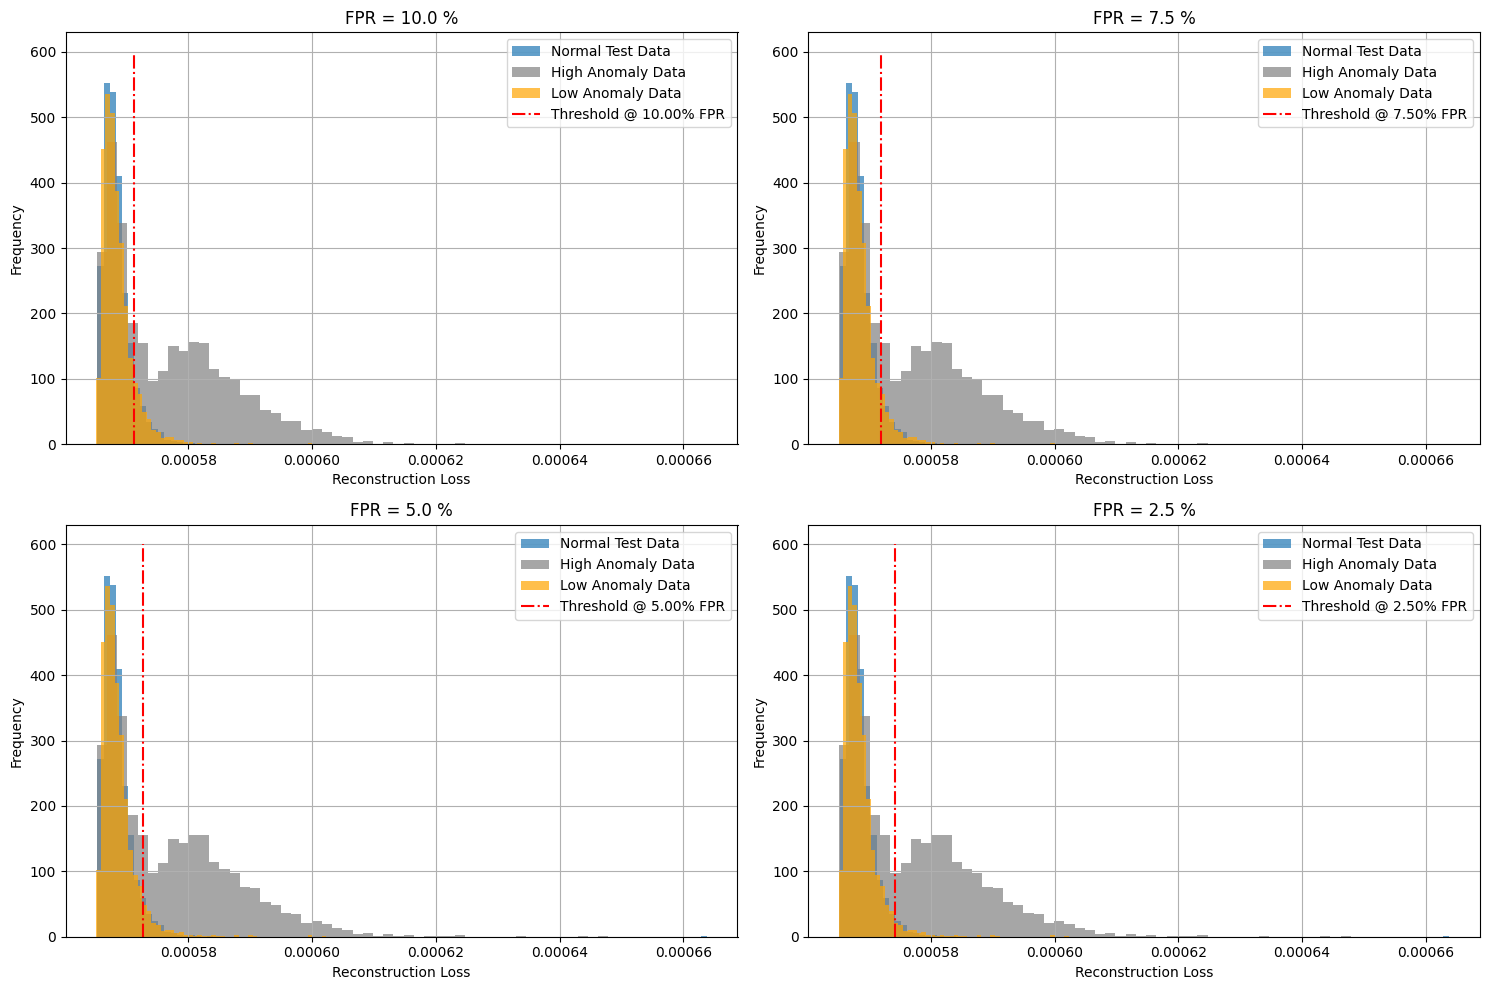

In [ ]:
# We try 4 different FPR (as told, lower or equal to 10%)
target_fpr_list = [0.1, 0.075, 0.05, 0.025]
results = []

# Bucle sobre cada FPR
for target_fpr in target_fpr_list:
    percentile_threshold = (1 - target_fpr) * 100 # percentile we are accepting as normal
    anomaly_threshold = np.percentile(as_normal_test, percentile_threshold)

    # High anomaly data
    detected_anomalies_tp = np.sum(np.array(as_tp) > anomaly_threshold)
    percentage_detected_tp = (detected_anomalies_tp / len(as_tp)) * 100

    # Low anomaly data
    detected_anomalies_td = np.sum(np.array(as_td) > anomaly_threshold)
    percentage_detected_td = (detected_anomalies_td / len(as_td)) * 100

    # Actual FPR, just to check it is equal to the target
    false_positives_normal_test = np.sum(np.array(as_normal_test) > anomaly_threshold)
    actual_fpr = (false_positives_normal_test / len(as_normal_test)) * 100

    # Results are saved
    results.append({
        'target_fpr': target_fpr * 100,
        'threshold': anomaly_threshold,
        'actual_fpr': actual_fpr,
        'anom_tp': percentage_detected_tp,
        'anom_td': percentage_detected_td
    })

print("")
print(f"{'Target FPR (%)':<15}{'Actual FPR (%)':<17}{'Threshold':<12}"
      f"{'Anom% High':<12}{'Anom% Low':<12}{'Δ (%)':<8}")
for res in results:
    diff = res['anom_tp'] - res['anom_td']
    print(f"{res['target_fpr']:<15.2f}{res['actual_fpr']:<17.2f}"
          f"{res['threshold']:<12.6f}{res['anom_tp']:<12.2f}"
          f"{res['anom_td']:<12.2f}{diff:<8.2f}")

print()


# Opcional: visualizar los histogramas para cada FPR
num_bins = 50
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()  # Para iterar fácilmente en 1D

for i, res in enumerate(results):
    anomaly_threshold = res['threshold']
    ax = axs[i]
    ax.hist(as_normal_test, bins=num_bins*2, label='Normal Test Data', alpha=0.7)
    ax.hist(as_tp, bins=num_bins, label='High Anomaly Data', alpha=0.7, color='gray')
    ax.hist(as_td, bins=num_bins, label='Low Anomaly Data', alpha=0.7, color='orange')
    ax.plot(np.full(10, anomaly_threshold), np.linspace(0, 600, 10),
            '-.', color='red', label=f'Threshold @ {res["target_fpr"]:.2f}% FPR')
    ax.set_title(f'FPR = {res["target_fpr"]:.1f} %')
    ax.set_xlabel("Reconstruction Loss")
    ax.set_ylabel("Frequency")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

We can analyse how well our data is interpreted by our autoencoder.
First of all, it is clear that the dataset containing a large number of anomalyies is highly differentiated. As we discussed earlier, through the PCA we predicted these anomalyies would differ greatly from the normal data. This means that, not only a myriad of data is classified as anomaly, but their loss is significantly far from normal data. This could hypothetically be seem as a Gaussian bell far from the normal data. This is just a bold hypothis to indicate what we refer at the graph, but we do not have any actual impirical data for this fact indeed.
Overall, we have determined the anomaly percentage to be **≈60%**.

In addition, the low anomaly dataset contains a lower number of anomalyies that we expected. As described earlier, even the anomaly data have close losses to our normal dataset. Nevertheless, using a *10% FPD*, we have still approximated the percentage found to **≈11.23%.**

Regarding which FPR we will use from now on, we have chosen a 10%. This is because using a stricter one (like 2.5 or 5%) counts too many anomalies as normal. However, 7.5% could have also been used.

#Clustering


##GMM
First we have tried a GMM clustering for our latent space with PCA component projection.

GMM fitted with 5 components.
Cluster assignments generated.

Distribution of Original Data Types in GMM Clusters:
Cluster 0:
  Total samples: 0
  Train Normal: 0 (nan%)
  Test Normal:  0 (nan%)
  Test Low Anomaly: 0 (nan%)
  Test High Anomaly: 0 (nan%)
Cluster 1:
  Total samples: 17992
  Train Normal: 9600 (53.36%)
  Test Normal:  2400 (13.34%)
  Test Low Anomaly: 3000 (16.67%)
  Test High Anomaly: 2992 (16.63%)
Cluster 2:
  Total samples: 0
  Train Normal: 0 (nan%)
  Test Normal:  0 (nan%)
  Test Low Anomaly: 0 (nan%)
  Test High Anomaly: 0 (nan%)
Cluster 3:
  Total samples: 8
  Train Normal: 0 (0.00%)
  Test Normal:  0 (0.00%)
  Test Low Anomaly: 0 (0.00%)
  Test High Anomaly: 8 (100.00%)
Cluster 4:
  Total samples: 0
  Train Normal: 0 (nan%)
  Test Normal:  0 (nan%)
  Test Low Anomaly: 0 (nan%)
  Test High Anomaly: 0 (nan%)


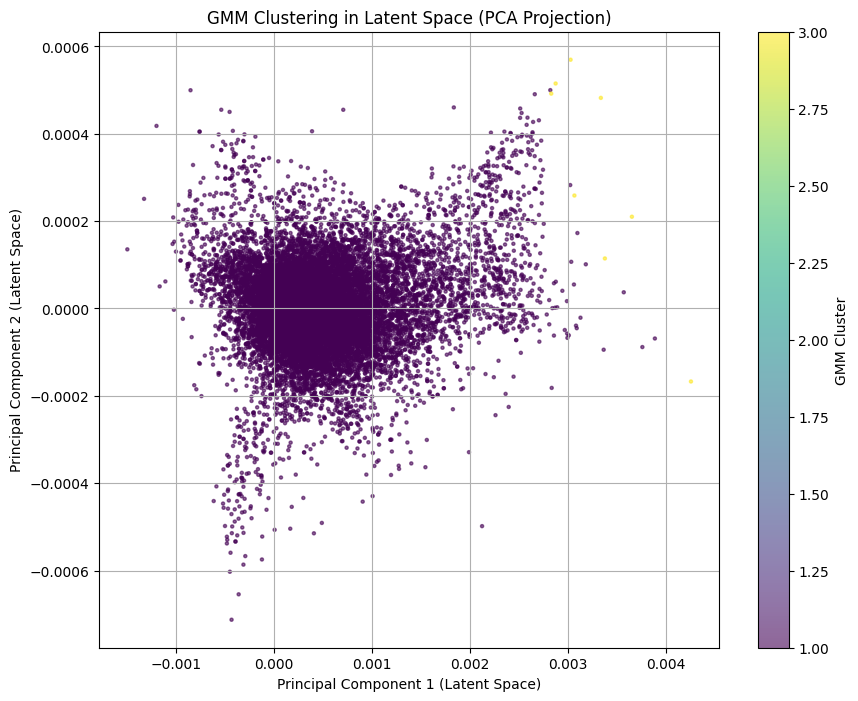

In [ ]:
#gmm
combined_latent_data = np.concatenate([X_train_latent, X_test_latent, test_data_l_latent, test_data_h_latent], axis=0) #repr dopo

# 0: Train Normal, 1: Test Normal, 2: Test Low Anomaly, 3: Test High Anomaly
combined_labels = np.concatenate([
    np.zeros(X_train_latent.shape[0]),
    np.ones(X_test_latent.shape[0]),
    np.full(test_data_l_latent.shape[0], 2),
    np.full(test_data_h_latent.shape[0], 3)
], axis=0)

n_components = 2
gmm = GaussianMixture(n_components=n_components, random_state=42, max_iter=10000, covariance_type='full') #covariance flexivility

gmm.fit(combined_latent_data)

cluster_assignments = gmm.predict(combined_latent_data)

combined_latent_pca = pca_latent.transform(combined_latent_data)

#reppresentation
plt.figure(figsize=(10, 8))
scatter = plt.scatter(combined_latent_pca[:, 0], combined_latent_pca[:, 1],
                      c=cluster_assignments, cmap='viridis', s=5, alpha=0.6)
plt.title('GMM Clustering in Latent Space (PCA Projection)')
plt.xlabel('Principal Component 1 (Latent Space)')
plt.ylabel('Principal Component 2 (Latent Space)')
plt.colorbar(scatter, label='GMM Cluster')
plt.grid(True)
plt.show()

We can see two clusters are slightly well discretized. Accuracy could still be improved.
Eventhough myriad of parameters were tried, this method could not fit our data into two different clusters well enough.
Even the covariance type was changed to full to allow GMM for more flexibility.

Thus, we do not fully comprehend why this method doesn't provides good enough results. One possibilty could be behind the latent space, as it could be better optimized to detect anomalies. In addition, the same method was applied at the UMAP representation, though the same result was obtained.

We can get a quick approximation of this data.

In [ ]:
cluster_2_data_indices = np.where(cluster_assignments == 1)[0]

original_labels_in_cluster_2 = combined_labels[cluster_2_data_indices]

#cluster 2 contains dati from anomalyus data
unique_labels, counts = np.unique(original_labels_in_cluster_2, return_counts=True)

print("Original data type distribution un Cluster 2:")
total_in_cluster_2 = len(cluster_2_data_indices)

for label, count in zip(unique_labels, counts):
    if label == 0:
        label_name = 'Train Normal'
    elif label == 1:
        label_name = 'Test Normal'
    elif label == 2:
        label_name = 'Test Low Anomaly'
    elif label == 3:
        label_name = 'Test High Anomaly'
    else:
        label_name = f'Unknown Label {int(label)}'

    percentage = (count / total_in_cluster_2) * 100
    print(f"  {label_name}: {count} ({percentage:.2f}%)")

anomaly_count_in_cluster_2 = np.sum((original_labels_in_cluster_2 == 2) | (original_labels_in_cluster_2 == 3))
percentage_anomaly_in_cluster_2 = (anomaly_count_in_cluster_2 / total_in_cluster_2) * 100
print(f"Percentage of Anomaly data (Low or High) detected in Cluster Anomaly: {percentage_anomaly_in_cluster_2:.2f}%")

total_anomaly_samples = test_data_l_latent.shape[0] + test_data_h_latent.shape[0]
percentage_of_total_anomaly_in_cluster_2 = (anomaly_count_in_cluster_2 / total_anomaly_samples) * 100
print(f"Percentage of total Anomaly data that falls into Cluster Anomaly: {percentage_of_total_anomaly_in_cluster_2:.2f}%")

Original data type distribution un Cluster 2:
  Train Normal: 11 (4.66%)
  Test Normal: 6 (2.54%)
  Test Low Anomaly: 7 (2.97%)
  Test High Anomaly: 212 (89.83%)
Percentage of Anomaly data (Low or High) detected in Cluster Anomaly: 92.80%
Percentage of total Anomaly data that falls into Cluster Anomaly: 3.65%


It can be seen that the second cluster highly gets the anomaly data (≈92%). Note however, how the total anomaly data falling into this cluster is far by the expected result (≈4%).

This is not perfect, as we would expect more data to fall into this category.

## K Means

Moreover, we have discuss whether K-Means could offer other results.

For this algorithim though, a higher number of clusters would be needed, as our data doesn't always fit to circular patterns.

In [ ]:
n_clusters_kmeans = 5
kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=10)

kmeans.fit(combined_latent_data)

kmeans_cluster_assignments = kmeans.predict(combined_latent_data)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(combined_latent_pca[:, 0], combined_latent_pca[:, 1],
                      c=kmeans_cluster_assignments, cmap='viridis', s=5, alpha=0.6)
plt.title(f'KMeans Clustering ({n_clusters_kmeans} Clusters) in Latent Space (PCA Projection)')
plt.xlabel('Principal Component 1 (Latent Space)')
plt.ylabel('Principal Component 2 (Latent Space)')
plt.colorbar(scatter, label='KMeans Cluster')
plt.grid(True)
plt.show()

NameError: name 'KMeans' is not defined

This algorithm fails to group our data into our desired clusters. Thus, no possible clustering was processed. This is probably due to the non-circular nature of our representation.



As a group, this has been highly disappointing for us, as we have tried myriad of approaches to improve our accuracy for this problem, but we haven't still been able to get better results for this part.

Lots of papers were read and extra research was made, which gave us the impression to be closer to the solution. However, GMM did not agree with us.

We were highly motivated to corroborate the results obtained in the first part.

Moreover, we were asking ourselves whether the low percentage of anomalyies detected for the low anomaly dataset with the clustering would match the ones obtained with the first method.

#Conclusions
In this artificial intelligence project, a system based on an autoencoder has been developed with the objective of detecting anomalous events within different data sets. The model has demonstrated an acceptable ability to differentiate between normal and anomalous events, especially when evaluating the loss function in each case.

From the reconstruction error analysis, it was found that the high dataset had a percentage of anomalies higher than 55%, while the low dataset contained less than 45% of anomalous events, which supports the model's ability to reflect structural differences between the datasets.

Subsequently, a clustering process and an evaluation of the purity of the clusters generated was carried out. Although the results obtained at this stage have not been optimal - possibly due to a not entirely rigorous separation between normal and anomalous by the autoencoder -, the system has been able to identify a significant proportion of anomalous events. This suggests a good starting point for future improvements, both in the model architecture and in the training strategy, in order to increase the accuracy and robustness of the system.